# 01 – Khám phá dữ liệu (EDA)

**Mục tiêu**
1. Hiểu cấu trúc, chất lượng và phân bố của dữ liệu giao dịch thẻ mua sắm.
2. Xác định nhãn và cách đặt bài toán phân loại loại chi phí.
3. Đối chiếu 9 quy tắc nghiệp vụ (R01–R09) trong bản phân tích với dữ liệu: rule nào áp dụng được, rule nào phải sinh thêm dữ liệu.

**Nguồn:** Oklahoma Purchase Card (PCard), data.ok.gov. Gồm 14 file theo tháng (07/2025 – 08/2026), đọc và làm sạch bằng `src/data_loader.py`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from src.data_loader import load_pcard

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)

BLUE, ORANGE, INK, INK2, GRID = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'font.family': ['Arial', 'DejaVu Sans'], 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': INK2, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'xtick.color': INK2, 'ytick.color': INK2,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'figure.dpi': 110, 'figure.facecolor': 'white',
})
thousands = mtick.FuncFormatter(lambda x, _: f'{x:,.0f}')

## 1. Tổng quan

In [2]:
df = load_pcard()
print(df.shape)
df.head()

(485616, 13)


,agency_id,agency,last_name,first_initial,item_desc,amount,merchant,tx_date,post_date,mcc_desc,month,cardholder_id,merchant_norm
0,01000,OKLAHOMA STATE UNIVERSITY,Schmitt,A,GENERAL PURCHASE,25.00,JOURNYHSE 0001906340017,2025-06-30,2025-07-01,TRAVEL AGENCIES,2025-07,01000|Schmitt|A,JOURNYHSE
1,01000,OKLAHOMA STATE UNIVERSITY,Scimeca,R,GENERAL PURCHASE,"1,632.50",MIDSCI,2025-06-30,2025-07-01,LAB/MEDICAL/DENTAL/OPHTHALMIC HOSPITAL E,2025-07,01000|Scimeca|R,MIDSCI
2,01000,OKLAHOMA STATE UNIVERSITY,Scimeca,R,Vacutainer Blood Collectio PCE|BH Supplies 10ml Lu,419.87,AMAZON MKTPL NQ0ZZ0I61,2025-06-30,2025-07-01,BOOK STORES,2025-07,01000|Scimeca|R,AMAZON MKTPL
3,01000,OKLAHOMA STATE UNIVERSITY,Seawright,J,GENERAL PURCHASE,-500.00,ROYAL CARIBBEAN CRUISES,2025-06-30,2025-07-01,STEAMSHIP/CRUISE LINES,2025-07,01000|Seawright|J,ROYAL CARIBBEAN CRUISES
4,01000,OKLAHOMA STATE UNIVERSITY,Siler,S,Facebook Ads EAC,111.49,FACEBK YTHFLTY2U2,2025-06-30,2025-07-01,ADVERTISING SERVICES,2025-07,01000|Siler|S,FACEBK YTHFLTY


In [3]:
print('Tháng hạch toán:', df.month.min(), '→', df.month.max(), f'({df.month.nunique()} tháng)')
print('Ngày giao dịch:', df.tx_date.min().date(), '→', df.tx_date.max().date())
pd.DataFrame({
    'kiểu': df.dtypes.astype(str),
    'rỗng': (df.astype(str) == '').sum(),
    'số giá trị khác nhau': df.nunique(),
})

Tháng hạch toán: 2025-07 → 2026-08 (14 tháng)
Ngày giao dịch: 2024-09-03 → 2026-08-31


,kiểu,rỗng,số giá trị khác nhau
agency_id,str,0,118
agency,str,0,118
last_name,str,0,4528
first_initial,str,0,36
item_desc,str,49,141471
amount,float64,0,103132
merchant,str,0,169428
tx_date,datetime64[us],0,456
post_date,datetime64[us],0,302
mcc_desc,str,0,429


Ý nghĩa các cột chính:
- `agency`: đơn vị (sở, trường đại học…); `cardholder_id`: người chi (ghép mã đơn vị + họ + chữ cái đầu tên).
- `item_desc`: mô tả mặt hàng; `merchant`: tên cửa hàng; `mcc_desc`: mô tả mã ngành hàng (MCC) của cửa hàng.
- `tx_date`: ngày giao dịch; `post_date`: ngày ghi sổ; `month`: tháng hạch toán (dùng để chia file).

**Chất lượng dữ liệu:** không có ô trống ở các cột quan trọng (chỉ 49 dòng thiếu mô tả mặt hàng). Các lỗi định dạng giữa các file (cột thừa, tên cột có khoảng trắng, số âm dạng `$(121.52)`) đã được xử lý trong `data_loader.py`.

## 2. Số tiền

count   485,616.00
mean        438.56
std       1,883.86
min     -28,605.86
25%          36.98
50%         120.00
75%         380.00
90%         947.12
99%       4,761.35
max     486,849.00
Name: amount, dtype: float64
Giao dịch âm (hoàn tiền / điều chỉnh): 16,546
Giao dịch trên $5.000: 3,906


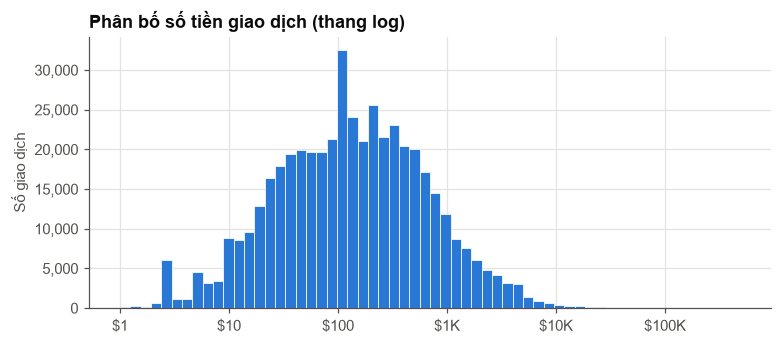

In [4]:
print(df.amount.describe(percentiles=[.25, .5, .75, .9, .99]))
print(f'Giao dịch âm (hoàn tiền / điều chỉnh): {(df.amount < 0).sum():,}')
print(f'Giao dịch trên $5.000: {(df.amount > 5000).sum():,}')

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(np.log10(df.amount[df.amount >= 1]), bins=60, color=BLUE, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(0, 6)); ax.set_xticklabels(['$1', '$10', '$100', '$1K', '$10K', '$100K'])
ax.yaxis.set_major_formatter(thousands)
ax.set_title('Phân bố số tiền giao dịch (thang log)'); ax.set_ylabel('Số giao dịch')
plt.show()

**Nhận xét:** trung vị khoảng $120 và 99% giao dịch dưới khoảng $4.800, nhưng có vài khoản lớn tới hàng trăm nghìn đô (thuê thiết bị, nhà thầu). Phân bố lệch mạnh nên khi làm đặc trưng cho mô hình cần dùng thang log. Khoảng 16,5 nghìn giao dịch âm là hoàn tiền, phải tách riêng khi kiểm tra rule.

## 3. Thời gian

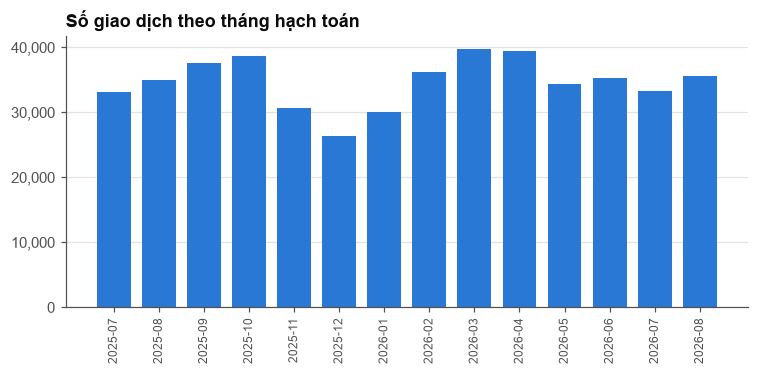

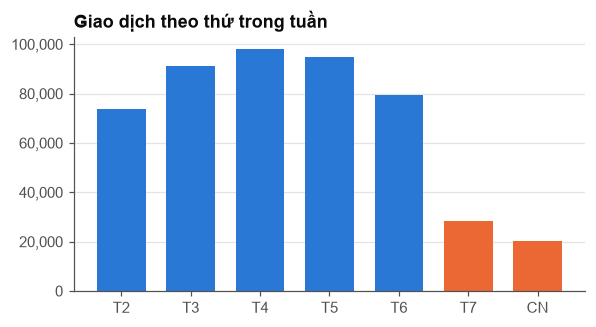

Giao dịch cuối tuần: 48,597 (10.0%)
Loại cửa hàng phổ biến nhất vào cuối tuần:
mcc_desc
BOOK STORES                                 13005
STATIONERY OFFICE SUPPLIES PRINTING AND      2651
VARIETY STORES                               1718
LAB/MEDICAL/DENTAL/OPHTHALMIC HOSPITAL E     1695
COMPUTER SOFTWARE STORES                     1603
EATING PLACES  RESTAURANTS                   1589

Độ trễ từ ngày giao dịch đến ngày ghi sổ: trung vị 1 ngày, 99% ≤ 5 ngày, lớn nhất 318 ngày


In [5]:
monthly = df.groupby('month').size()
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(monthly.index.astype(str), monthly.values, color=BLUE, width=0.75)
ax.set_title('Số giao dịch theo tháng hạch toán'); ax.yaxis.set_major_formatter(thousands)
ax.tick_params(axis='x', rotation=90, labelsize=8); ax.grid(axis='x', visible=False)
plt.show()

wd = df.tx_date.dt.dayofweek.value_counts().reindex(range(7), fill_value=0)
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(['T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'CN'], wd.values,
       color=[ORANGE if i >= 5 else BLUE for i in range(7)], width=0.7)
ax.set_title('Giao dịch theo thứ trong tuần'); ax.yaxis.set_major_formatter(thousands)
ax.grid(axis='x', visible=False)
plt.show()
weekend = df.tx_date.dt.dayofweek >= 5
print(f'Giao dịch cuối tuần: {weekend.sum():,} ({weekend.mean():.1%})')
print('Loại cửa hàng phổ biến nhất vào cuối tuần:')
print(df[weekend].mcc_desc.value_counts().head(6).to_string())
lag = (df.post_date - df.tx_date).dt.days
print(f'\nĐộ trễ từ ngày giao dịch đến ngày ghi sổ: trung vị {lag.median():.0f} ngày, 99% ≤ {lag.quantile(.99):.0f} ngày, lớn nhất {lag.max()} ngày')

**Nhận xét:**
- Số giao dịch khá đều giữa các tháng (26–40 nghìn), tháng 12 giảm do kỳ nghỉ.
- 10% giao dịch rơi vào cuối tuần, nhưng phần lớn là **mua online** (Amazon được ghi nhận là "BOOK STORES") và ăn uống, công tác. Vì vậy rule R09 (giao dịch ngày nghỉ) nên để mức cảnh báo **Thấp**, và chỉ nâng mức khi kết hợp với tín hiệu khác.
- Một số giao dịch được ghi sổ trễ rất lâu so với ngày mua (tới 318 ngày), có thể dùng làm tín hiệu bất thường.

## 4. Đơn vị và người chi

Số đơn vị: 118 | Số người chi: 6,582


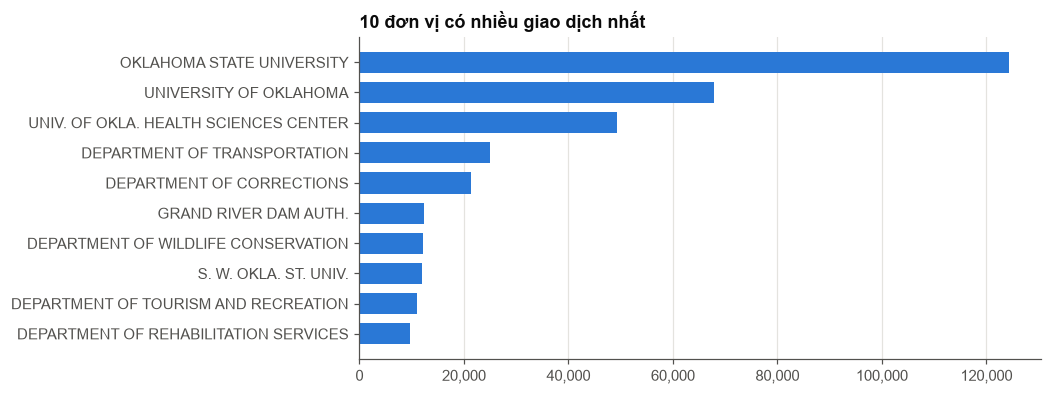

Số giao dịch mỗi người chi trong 14 tháng:
count   6,582.00
mean       74.00
std       197.00
min         1.00
50%        28.00
90%       168.00
99%       676.00
max     7,806.00


In [6]:
print(f'Số đơn vị: {df.agency.nunique()} | Số người chi: {df.cardholder_id.nunique():,}')
top_ag = df.agency.value_counts().head(10)[::-1]
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(top_ag.index, top_ag.values, color=BLUE, height=0.7)
ax.set_title('10 đơn vị có nhiều giao dịch nhất'); ax.xaxis.set_major_formatter(thousands)
ax.grid(axis='y', visible=False)
plt.show()

per_holder = df.groupby('cardholder_id').size()
print('Số giao dịch mỗi người chi trong 14 tháng:')
print(per_holder.describe(percentiles=[.5, .9, .99]).round(0).to_string())

**Nhận xét:**
- Ba trường đại học (OSU, OU, OU Health Sciences) chiếm khoảng một nửa số giao dịch.
- Mỗi người chi có trung vị 28 giao dịch trong 14 tháng: đủ lịch sử để mô hình bất thường học được "mức chi bình thường" của từng người, và đủ để áp dụng các rule theo người như hạn mức (R02) hay chia nhỏ giao dịch (R04).
- **Hạn chế:** `cardholder_id` ghép từ họ và chữ cái đầu tên nên hai người trùng họ, trùng chữ cái đầu trong cùng đơn vị sẽ bị gộp làm một.

## 5. Cửa hàng, mã ngành hàng (MCC) và mô tả mặt hàng

Số mã MCC: 429 | MCC có ≥ 500 giao dịch: 111 | Số MCC phủ 90% giao dịch: 79
Tên cửa hàng gốc: 169,428 | Sau chuẩn hóa: 34,139


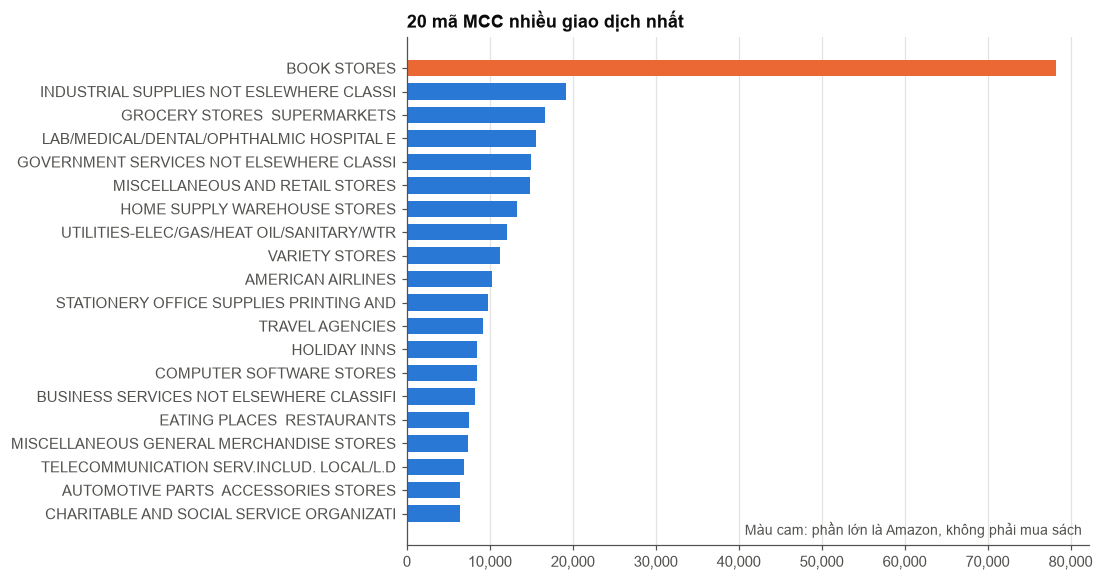

In [7]:
vc = df.mcc_desc.value_counts()
print(f'Số mã MCC: {len(vc)} | MCC có ≥ 500 giao dịch: {(vc >= 500).sum()} | Số MCC phủ 90% giao dịch: {int((vc.cumsum() / vc.sum() < .9).sum()) + 1}')
print(f'Tên cửa hàng gốc: {df.merchant.nunique():,} | Sau chuẩn hóa: {df.merchant_norm.nunique():,}')

top = vc.head(20)[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color=[ORANGE if i == 'BOOK STORES' else BLUE for i in top.index], height=0.7)
ax.set_title('20 mã MCC nhiều giao dịch nhất'); ax.xaxis.set_major_formatter(thousands)
ax.grid(axis='y', visible=False)
ax.text(0.99, 0.02, 'Màu cam: phần lớn là Amazon, không phải mua sách', transform=ax.transAxes,
        ha='right', fontsize=9, color=INK2)
plt.show()

In [8]:
amazon = df.merchant.str.contains('AMAZON|AMZN', case=False)
print(f'Giao dịch Amazon: {amazon.sum():,} ({amazon.mean():.1%})')
print('MCC của các giao dịch Amazon:')
print(df[amazon].mcc_desc.value_counts().head(4).to_string())
print(f"\nGiao dịch 'BOOK STORES' không phải Amazon: {((df.mcc_desc == 'BOOK STORES') & ~amazon).sum():,}")
df[amazon & (df.item_desc != 'GENERAL PURCHASE')][['item_desc', 'amount', 'mcc_desc']].sample(8, random_state=3)

Giao dịch Amazon: 94,681 (19.5%)
MCC của các giao dịch Amazon:
mcc_desc
BOOK STORES                              77755
VARIETY STORES                           10162
MISCELLANEOUS AND RETAIL STORES           6297
COMPUTER NETWORK/INFORMATION SERVICES      301

Giao dịch 'BOOK STORES' không phải Amazon: 540


,item_desc,amount,mcc_desc
334370,Elite Sports Kids Wrestlin PCE,47.97,BOOK STORES
106729,Bonide Captain Jack s Citr PCE,21.97,BOOK STORES
477276,ExcelMark Custom Name Plat PCE|ExcelMark Custom Na,20.88,BOOK STORES
438354,Dell 27 Plus 4K USB-C Moni PCE,617.98,BOOK STORES
390978,Order Summary item,143.97,VARIETY STORES
340209,Bambu Lab P1S + AMS (Combo PCE,"2,318.85",BOOK STORES
10340,Start with Why: How Great PCE|StrengthsFinder 2.0,526.63,BOOK STORES
450345,Gatorade Zero Sugar Electr PCE|Gatorade Zero Sugar,36.16,BOOK STORES


In [9]:
generic = df.item_desc.str.upper().isin(['GENERAL PURCHASE', 'ORDER SUMMARY ITEM', ''])
print(f'Mô tả mặt hàng chung chung ("GENERAL PURCHASE"…): {generic.mean():.1%} tổng số, {generic[amazon].mean():.1%} với Amazon')

majority = df.groupby('merchant_norm').mcc_desc.agg(lambda s: s.value_counts(normalize=True).iloc[0])
print(f'Độ chính xác nếu đoán MCC phổ biến nhất của cửa hàng: {df.merchant_norm.map(majority).mean():.1%}')
train, test = df[df.month < pd.Period('2026-06', 'M')], df[df.month >= pd.Period('2026-06', 'M')]
print(f'Giao dịch 06–08/2026 ở cửa hàng chưa xuất hiện trước đó: {(~test.merchant_norm.isin(train.merchant_norm)).mean():.1%}')

Mô tả mặt hàng chung chung ("GENERAL PURCHASE"…): 40.2% tổng số, 21.0% với Amazon


Độ chính xác nếu đoán MCC phổ biến nhất của cửa hàng: 98.7%
Giao dịch 06–08/2026 ở cửa hàng chưa xuất hiện trước đó: 7.1%


**Nhận xét, đây là phần quyết định cách đặt bài toán phân loại:**
- MCC là thuộc tính **của cửa hàng**, do ngân hàng gán, không phải loại chi phí hạch toán. Chỉ cần tra tên cửa hàng là đoán đúng MCC khoảng 99%. Vì vậy phân loại dựa trên tên cửa hàng sẽ quá dễ và ít giá trị thực tế.
- **Amazon chiếm khoảng 20% giao dịch**, và gần như bị gán "BOOK STORES" bất kể mua gì (ổ cứng, hóa chất, đồ lau dọn…). Với nhóm này nhãn MCC **sai về mặt nghiệp vụ**. Trong khi đó khoảng 79% giao dịch Amazon có mô tả mặt hàng rõ ràng.
- Có 429 mã MCC, nhiều mã chỉ là tên thương hiệu (từng hãng bay, từng chuỗi khách sạn). Cần **gom thành khoảng 12–15 nhóm chi phí** (công tác – vé máy bay, lưu trú, ăn uống, văn phòng phẩm, CNTT, thiết bị phòng thí nghiệm – y tế, vật tư công nghiệp, tiện ích…).

**Hướng đề xuất:** huấn luyện mô hình phân loại dựa vào **mô tả mặt hàng + tên cửa hàng + số tiền**, với nhãn là nhóm MCC, dùng các giao dịch không phải Amazon. Sau đó áp dụng để **phân loại lại giao dịch Amazon**, nơi MCC không dùng được. Những ca mô hình không chắc chắn sẽ chuyển cho LLM. Để đánh giá phần Amazon cần một tập nhỏ (vài trăm giao dịch) được gán nhãn thủ công.

## 6. Đối chiếu quy tắc nghiệp vụ với dữ liệu

Dữ liệu công khai không có hạn mức thật, nên các ngưỡng dưới đây là **giả định** để thử nghiệm (hạn mức $5.000/giao dịch). Mục đích là kiểm tra rule có dữ liệu để chạy không, và số cảnh báo sinh ra có hợp lý không.

In [10]:
LIMIT = 5_000
pos = df[df.amount > 0]
travel = pos.item_desc.isin(['ROOM CHARGES', 'AIR TRAVEL'])

def near_duplicates(d, keys, days=3):
    d = d.sort_values('tx_date')
    gap = d.groupby(keys + ['amount']).tx_date.diff().dt.days
    return int((gap <= days).sum())

def split_windows(d, keys, limit, days=7):
    d = d[d.amount < limit].sort_values(keys + ['tx_date'])
    r = d.set_index('tx_date').groupby(keys).amount.rolling(f'{days}D').agg(['sum', 'count'])
    return int(((r['count'] >= 2) & (r['sum'] >= limit)).sum())

first_seen = df.groupby('merchant_norm').month.min()
new_merchant = df.month.ge(pd.Period('2026-01', 'M')) & df.merchant_norm.map(first_seen).ge(pd.Period('2026-01', 'M'))
restricted = df.mcc_desc.str.contains(r'CASINO|PACKAGE STORES|DRINKING PLACES|CIGAR|MASSAGE|JEWELRY', regex=True)
cash_like = df.mcc_desc.isin(['WIRE TRANSFER MONEY ORDERS', 'POI FUNDING TRANSACTIONS EXCLUDING MONEYSEND'])
exact_dup = df.duplicated(['cardholder_id', 'merchant', 'item_desc', 'amount', 'tx_date', 'post_date', 'mcc_desc'])

signals = pd.DataFrame([
    ('R01', 'Mô tả mặt hàng chung chung / trống (thay cho thiếu chứng từ)', int(generic.sum())),
    ('R02', f'Vượt hạn mức ${LIMIT:,}/giao dịch', int((df.amount > LIMIT).sum())),
    ('R03', 'Trùng hoàn toàn mọi trường', int(exact_dup.sum())),
    ('R03', '(lỏng) Người chi + cửa hàng + số tiền, cách nhau ≤ 3 ngày', near_duplicates(pos, ['cardholder_id', 'merchant_norm'])),
    ('R03', '(chặt) Như trên, loại tiền phòng & vé máy bay', near_duplicates(pos[~travel], ['cardholder_id', 'merchant_norm'])),
    ('R04', f'(lỏng) Người chi + cửa hàng, 7 ngày, mỗi khoản < ${LIMIT:,}, tổng ≥ ${LIMIT:,}', split_windows(pos, ['cardholder_id', 'merchant_norm'], LIMIT)),
    ('R04', '(chặt) Như trên nhưng trong 3 ngày, mỗi khoản ≥ $1,000', split_windows(pos[pos.amount >= 1000], ['cardholder_id', 'merchant_norm'], LIMIT, days=3)),
    ('R06', 'Chuyển tiền / nạp tiền (tương đương tiền mặt)', int(cash_like.sum())),
    ('R07', 'Cửa hàng lần đầu xuất hiện (từ 01/2026)', int(new_merchant.sum())),
    ('R08', 'MCC hạn chế: casino, rượu, quán bar, thuốc lá, massage, trang sức', int(restricted.sum())),
    ('R09', 'Giao dịch cuối tuần', int(weekend.sum())),
], columns=['Mã', 'Tín hiệu kiểm tra trên dữ liệu', 'Số dòng'])
signals['% tổng'] = (signals['Số dòng'] / len(df) * 100).round(2)
signals

,Mã,Tín hiệu kiểm tra trên dữ liệu,Số dòng,% tổng
0,R01,Mô tả mặt hàng chung chung / trống (thay cho thiếu chứng...,195045,40.16
1,R02,"Vượt hạn mức $5,000/giao dịch",3906,0.80
2,R03,Trùng hoàn toàn mọi trường,27069,5.57
3,R03,"(lỏng) Người chi + cửa hàng + số tiền, cách nhau ≤ 3 ngày",44528,9.17
4,R03,"(chặt) Như trên, loại tiền phòng & vé máy bay",21540,4.44
5,R04,"(lỏng) Người chi + cửa hàng, 7 ngày, mỗi khoản < $5,000,...",18413,3.79
6,R04,"(chặt) Như trên nhưng trong 3 ngày, mỗi khoản ≥ $1,000",3065,0.63
7,R06,Chuyển tiền / nạp tiền (tương đương tiền mặt),170,0.04
8,R07,Cửa hàng lần đầu xuất hiện (từ 01/2026),28997,5.97
9,R08,"MCC hạn chế: casino, rượu, quán bar, thuốc lá, massage, ...",523,0.11


In [11]:
print('Chi tiết R08 theo MCC:')
print(df[restricted].mcc_desc.value_counts().to_string())

Chi tiết R08 theo MCC:
mcc_desc
DRINKING PLACES (ALCOHOLIC BEV.)-BARS TA    207
CAESARS HOTEL AND CASINO                     79
JEWELRY STORES-WATCHES  CLOCKES  AND SIL     59
PACKAGE STORES  BEER  LIQUOR                 57
BEAU RIVAGE HOTEL AND CASINO                 34
LUXOR HOTEL AND CASINO                       23
PEPPERMILL HOTEL CASINO                      20
CIGAR STORES AND STANDS                      12
HARRAH S HOTELS AND CASINOS                   9
BALLY S HOTEL AND CASINO                      8
VENETIAN RESORT HOTEL AND CASINO              4
WATCH  CLOCK AND JEWELRY REPAIR               3
MONTE CARLO HOTEL AND CASINO                  2
SAM S TOWN HOTEL AND CASINO                   2
SILVER LEGACY HOTEL AND CASINO                1
TREASURE ISLAND HOTEL AND CASINO              1
NEW YORK-NEW YORK HOTEL + CASINO              1
MASSAGE PARLORS                               1


In [12]:
d = pos.sort_values('tx_date')
flag = d.groupby(['cardholder_id', 'merchant_norm', 'amount']).tx_date.diff().dt.days <= 3
print('R03 (lỏng) – mô tả mặt hàng của các giao dịch bị gắn cờ:')
print(d[flag].item_desc.value_counts().head(5).to_string())

R03 (lỏng) – mô tả mặt hàng của các giao dịch bị gắn cờ:
item_desc
GENERAL PURCHASE                 15034
ROOM CHARGES                     12567
AIR TRAVEL                       10403
FINANCIAL ACCOUNTING SERVI EA      284
Order Summary item                 218


**Nhận xét:**
- Tất cả rule trừ R05 đều có dữ liệu để chạy. Tuy nhiên, **nếu áp dụng máy móc, số cảnh báo quá lớn**: phiên bản "lỏng" của R03 gắn cờ khoảng 9% giao dịch, R04 khoảng 4%, R09 khoảng 10%. Kế toán không thể xem hết.
- Nguyên nhân chính của R03 là **tiền phòng khách sạn tính theo đêm** (cùng người, cùng khách sạn, cùng số tiền trong các ngày liên tiếp) và **vé máy bay mua cho cả đoàn**, đều là chi tiêu hợp lệ. Loại hai nhóm này thì R03 giảm từ khoảng 9,2% xuống 4,4%, vẫn còn cao. Phần còn lại chủ yếu là các khoản "GENERAL PURCHASE" lặp lại (phí dịch vụ công, mua định kỳ), mà rule không đủ thông tin để phân biệt. Đây là chỗ cần **mô hình bất thường** (học thói quen mua lặp của từng người) và **LLM** hỗ trợ.
- Với R04, siết điều kiện (3 ngày, mỗi khoản ≥ $1.000) làm số cảnh báo giảm từ 3,8% xuống 0,6%, là mức kiểm tra được.
- Hai điểm trên là minh chứng cụ thể: **ngưỡng rule phải được tinh chỉnh trên dữ liệu thật**, và rule đơn thuần không đủ để kiểm soát giao dịch.
- **R08** cho thấy giới hạn của rule thuần túy: nhiều giao dịch "casino" thực ra là **khách sạn có casino** ở Las Vegas khi đi công tác, là chi phí lưu trú hợp lệ. Rule chỉ nên gắn cờ, còn LLM giải thích ngữ cảnh (có vé máy bay cùng thời điểm, mô tả là "ROOM CHARGES") để kế toán quyết định nhanh.
- **R01** (mô tả chung chung) chiếm khoảng 40% và **R09** (cuối tuần) khoảng 10%. Hai tín hiệu này quá phổ biến để tự đứng thành cảnh báo, nên chỉ dùng ở mức Thấp hoặc kết hợp với tín hiệu khác (ví dụ số tiền lớn).
- **R07**: khoảng 6% giao dịch từ 01/2026 là ở cửa hàng mới. Đây là tín hiệu hữu ích cho mô hình bất thường, không nên thành cảnh báo riêng.

## 7. Kết luận

In [13]:
pd.DataFrame([
    ('R01', 'Thiếu chứng từ', 'Một phần', 'Không có hóa đơn; dùng mô tả mặt hàng chung chung làm tín hiệu thay thế'),
    ('R02', 'Vượt hạn mức phê duyệt', 'Có (ngưỡng giả định)', 'Cấu hình hạn mức theo đơn vị / người chi'),
    ('R03', 'Trùng hóa đơn', 'Có', 'Phải loại tiền phòng theo đêm, vé máy bay đoàn'),
    ('R04', 'Chia nhỏ giao dịch', 'Có', 'Có người chi; dùng cửa sổ 3 ngày, khoản ≥ $1.000'),
    ('R05', 'Vượt ngân sách', 'Không', 'Sinh ngân sách từ chi tiêu lịch sử theo đơn vị × nhóm chi phí × tháng'),
    ('R06', 'Thanh toán tiền mặt', 'Một phần', 'Chỉ có MCC chuyển tiền; không có thông tin hình thức thanh toán'),
    ('R07', 'Nhà cung cấp chưa duyệt', 'Mô phỏng được', 'Coi cửa hàng đã xuất hiện trong các tháng đầu là "đã duyệt"'),
    ('R08', 'Loại chi phí bị cấm', 'Có', 'Danh sách MCC hạn chế; cần LLM giải thích ngữ cảnh'),
    ('R09', 'Giao dịch ngày nghỉ', 'Có', 'Mức Thấp; phần lớn là mua online'),
], columns=['Mã', 'Quy tắc', 'Dữ liệu có sẵn?', 'Ghi chú'])

,Mã,Quy tắc,Dữ liệu có sẵn?,Ghi chú
0,R01,Thiếu chứng từ,Một phần,Không có hóa đơn; dùng mô tả mặt hàng chung chung làm tí...
1,R02,Vượt hạn mức phê duyệt,Có (ngưỡng giả định),Cấu hình hạn mức theo đơn vị / người chi
2,R03,Trùng hóa đơn,Có,"Phải loại tiền phòng theo đêm, vé máy bay đoàn"
3,R04,Chia nhỏ giao dịch,Có,"Có người chi; dùng cửa sổ 3 ngày, khoản ≥ $1.000"
4,R05,Vượt ngân sách,Không,Sinh ngân sách từ chi tiêu lịch sử theo đơn vị × nhóm ch...
5,R06,Thanh toán tiền mặt,Một phần,Chỉ có MCC chuyển tiền; không có thông tin hình thức tha...
6,R07,Nhà cung cấp chưa duyệt,Mô phỏng được,"Coi cửa hàng đã xuất hiện trong các tháng đầu là ""đã duyệt"""
7,R08,Loại chi phí bị cấm,Có,Danh sách MCC hạn chế; cần LLM giải thích ngữ cảnh
8,R09,Giao dịch ngày nghỉ,Có,Mức Thấp; phần lớn là mua online


**Tóm tắt**
1. **Dữ liệu:** 485 nghìn giao dịch, 14 tháng, khoảng 6.600 người chi, 118 đơn vị. Chất lượng tốt sau khi làm sạch định dạng.
2. **Phân loại chi phí:** không phân loại theo tên cửa hàng (quá dễ, khoảng 99%). Thay vào đó phân loại theo **mô tả mặt hàng**, gom 429 MCC thành khoảng 12–15 nhóm, và áp dụng cho **giao dịch Amazon** (20% dữ liệu), nơi MCC sai về nghiệp vụ.
3. **Rule:** 8/9 rule có dữ liệu để chạy (R05 phải sinh ngân sách). Ngưỡng phải tinh chỉnh: phiên bản lỏng sinh quá nhiều cảnh báo giả, chủ yếu do tiền phòng khách sạn và vé máy bay đoàn.
4. **Phát hiện bất thường:** đủ lịch sử theo người chi và cửa hàng. Tín hiệu tiềm năng: số tiền lệch so với thói quen của người chi, cửa hàng mới, ghi sổ trễ, giao dịch trùng.
5. **Bước tiếp theo:** thiết kế bảng gom nhóm MCC → nhóm chi phí (cần duyệt), sau đó huấn luyện mô hình phân loại baseline.